In [49]:
# Celda 1: Importación de librerías
import pandas as pd
import numpy as np
import time
import json
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from itertools import cycle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    roc_curve, 
    auc
)
from sklearn.preprocessing import label_binarize

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [50]:
# Celda 2: Configuración del modelo específico desde JSON
# 🎯 Cargar configuración del modelo tradicional desde archivo JSON

params_path = r"C:\Users\Usuario\Documents\Workspace\Mirage\TFG\dataset\tradicional_params_undersampling.json"

# Cargar parámetros desde JSON
with open(params_path, "r") as f:
    all_params = json.load(f)

# Seleccionar dataset
dataset_type = "descripciones"  # Cambia a "codigos", "descripciones" o "combinado"

# Obtener configuración específica para el dataset
config = all_params[dataset_type]
model_type = config.get("model_type", "LogisticRegression")
max_features = config.get("max_features", 5000)
ngram_range = tuple(config.get("ngram_range", [1, 2]))

print(f"🔧 Configuración del modelo cargada desde JSON:")
print(f"Modelo: {model_type}")
print(f"Max Features (TF-IDF): {max_features}")
print(f"N-Gram Range: {ngram_range}")
print(f"Dataset: {dataset_type}")

🔧 Configuración del modelo cargada desde JSON:
Modelo: LightGBM
Max Features (TF-IDF): 5000
N-Gram Range: (1, 2)
Dataset: descripciones


In [ ]:
# Celda 3: Carga y preparación de datos (Dataset pre-dividido Train/Test para VAE)
import pandas as pd
import numpy as np
from collections import Counter

# 📁 Ruta base donde se encuentran los archivos pre-divididos
base_path = r"C:\Users\Usuario\Documents\Workspace\Mirage\TFG\dataset\dataset_finales\VAE"

# ✅ Carga de conjuntos de train y test según el tipo de dataset
if dataset_type == "codigos":
    path_train = f"{base_path}\\train_Dataset_procesable.csv"
    path_test = f"{base_path}\\test_Dataset_procesable.csv"
elif dataset_type == "descripciones":
    path_train = f"{base_path}\\train_dataset_descripciones.csv"
    path_test = f"{base_path}\\test_dataset_descripciones.csv"
else:  # combinado
    path_train = f"{base_path}\\train_diagnosticos_combinados.csv"
    path_test = f"{base_path}\\test_diagnosticos_combinados.csv"

# Cargar DataFrames
df_train = pd.read_csv(path_train, sep="|")
df_test = pd.read_csv(path_test, sep="|")

# Mapeo manual de códigos para asegurar la misma correspondencia clase-número
codes = ["F20", "F21", "F22", "F23", "F25", "F29", "F60.1"]
code2label = {code: idx for idx, code in enumerate(codes)}

# Filtrar por los códigos de interés
df_train = df_train[df_train["DIAG PSQ"].isin(codes)].copy()
df_test = df_test[df_test["DIAG PSQ"].isin(codes)].copy()

# Concatenar las columnas de diagnóstico para construir el texto de entrada
diag_cols_train = [col for col in df_train.columns if col.startswith("Diag")]
diag_cols_test = [col for col in df_test.columns if col.startswith("Diag")]

df_train["text"] = df_train[diag_cols_train].fillna("").apply(lambda x: " ".join(x), axis=1)
df_test["text"] = df_test[diag_cols_test].fillna("").apply(lambda x: " ".join(x), axis=1)

# Asignación final de variables para el pipeline
X_train = df_train["text"]
y_train = df_train["DIAG PSQ"].map(code2label)

X_test = df_test["text"]
y_test = df_test["DIAG PSQ"].map(code2label)

print(f"Labels únicos en Train: {np.sort(y_train.unique())}")
print(f"Labels únicos en Test: {np.sort(y_test.unique())}")
print(f"Número de clases: {len(codes)}")

print("\n📊 Distribución de datos:")
print("Entrenamiento:", Counter(y_train))
print("Evaluación:", Counter(y_test))
print(f"Total ejemplos (Train + Test): {len(df_train) + len(df_test)}")

Labels únicos: [0 4 5 3 2 6 1]
Número de labels únicos: 7
📊 Distribución de datos:
Entrenamiento: Counter({0: 400, 2: 216, 5: 119, 4: 88, 3: 56, 6: 10, 1: 6})
Evaluación: Counter({0: 100, 2: 54, 5: 30, 4: 22, 3: 14, 6: 3, 1: 1})
Total ejemplos: 1119


Total ejemplos: 1119
Clases únicas: [0 4 5 3 2 6 1]


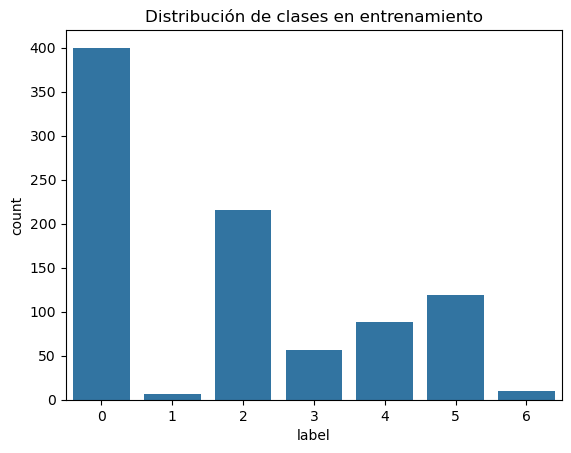

In [52]:
# Celda 4: Visualización de datos
print(f"Total ejemplos: {len(df)}")
print(f"Clases únicas: {df['label'].unique()}")

sns.countplot(x=y_train)
plt.title("Distribución de clases en entrenamiento")
plt.show()

In [53]:
# Celda 5: Definición de funciones de métricas
def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0)
    }

In [54]:
# Celda 6: Entrenamiento del modelo tradicional
print(f"\n🚀 Iniciando entrenamiento del modelo: {model_type}")

# Extraer solo los hiperparámetros reales del JSON (sin metadatos como "model_type")
model_config = {k: v for k, v in config.items() if k != "model_type"}

# Selección de clasificador según la configuración del JSON
if model_type == "XGBoost":
    clf = XGBClassifier(
        random_state=seed,
        n_jobs=-1,
        **model_config
    )
elif model_type == "LightGBM":
    clf = LGBMClassifier(
        random_state=seed,
        n_jobs=-1,
        **model_config
    )
elif model_type == "GradientBoosting":
    clf = GradientBoostingClassifier(
        random_state=seed,
        **model_config
    )
else:
    raise ValueError(f"Modelo no soportado: {model_type}")

# Construir el Pipeline (Vectorizador TF-IDF + Clasificador)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)),
    ('clf', clf)
])

print("⏳ Entrenando modelo...")
pipeline.fit(X_train, y_train)
print("✅ Entrenamiento completado.")


🚀 Iniciando entrenamiento del modelo: LightGBM
⏳ Entrenando modelo...


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008363 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11504
[LightGBM] [Info] Number of data points in the train set: 895, number of used features: 468
[LightGBM] [Info] Start training from score -0.805359
[LightGBM] [Info] Start training from score -5.005064
[LightGBM] [Info] Start training from score -1.421545
[LightGBM] [Info] Start training from score -2.771472
[LightGBM] [Info] Start training from score -2.319487
[LightGBM] [Info] Start training from score -2.017700
[LightGBM] [Info] Start training from score -4.494239
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

In [55]:
# Celda 7: Evaluación y resultados
print("\n📊 Evaluando modelo...")
y_pred = pipeline.predict(X_test)
metrics = compute_metrics(y_test, y_pred)

print(f"\n🏆 Resultados finales:")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1-Score: {metrics['f1']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")

# Crear resumen de resultados
resultado_final = {
    "modelo": model_type,
    "dataset": dataset_type,
    "max_features": max_features,
    "ngram_range": list(ngram_range),
    **{k: v for k, v in config.items() if k != "model_type"},
    "accuracy": metrics["accuracy"],
    "f1": metrics["f1"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "seed": seed
}

print(f"\n📋 Configuración utilizada:")
for key, value in resultado_final.items():
    print(f"{key}: {value}")


📊 Evaluando modelo...

🏆 Resultados finales:
Accuracy: 0.5179
F1-Score: 0.4880
Precision: 0.4805
Recall: 0.5179

📋 Configuración utilizada:
modelo: LightGBM
dataset: descripciones
max_features: 5000
ngram_range: [1, 2]
colsample_bytree: 1.0
num_leaves: 15
learning_rate: 0.1
max_depth: 3
n_estimators: 100
subsample: 0.8
accuracy: 0.5178571428571429
f1: 0.4880155562146444
precision: 0.48048330019030516
recall: 0.5178571428571429
seed: 124812300


c:\Users\Usuario\miniforge3\envs\alba\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📈 Generando curva ROC...


c:\Users\Usuario\miniforge3\envs\alba\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


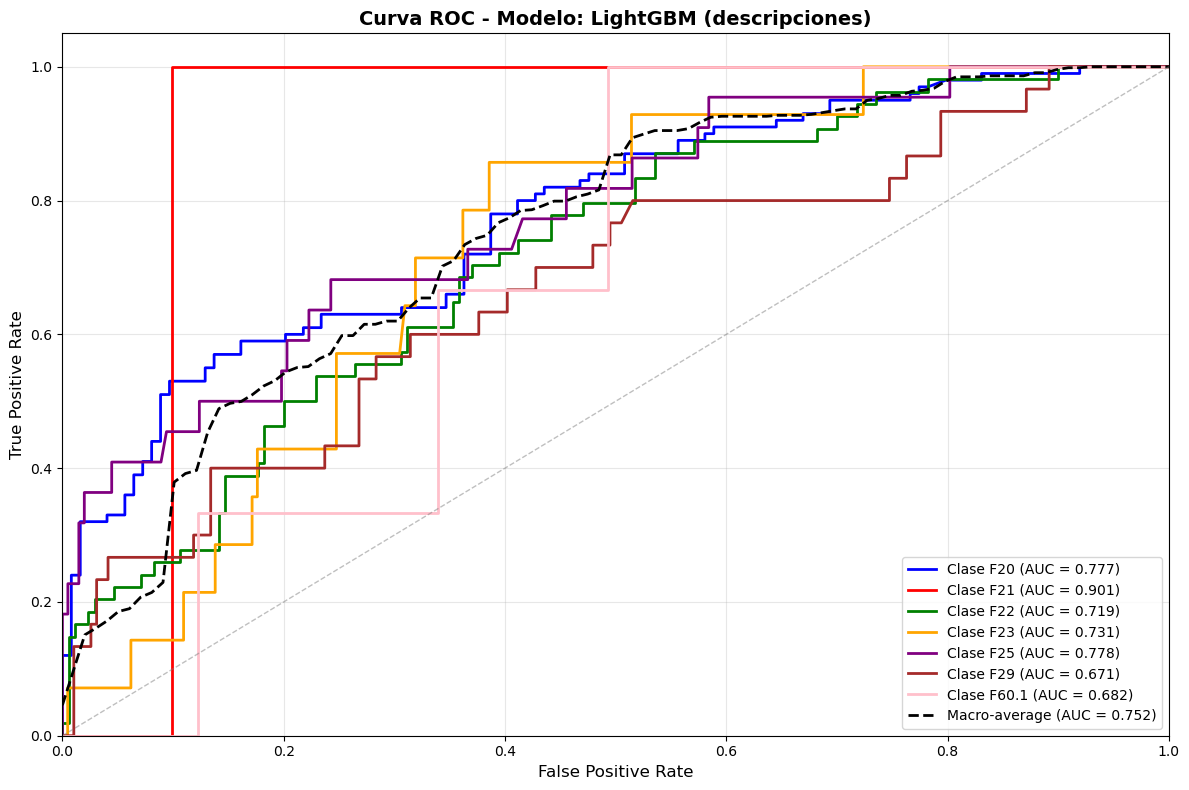

✅ Curva ROC guardada en: ./results/LightGBM_descripciones/roc_curve.png

📊 AUC Scores por clase:
  Clase F20: 0.7771
  Clase F21: 0.9013
  Clase F22: 0.7185
  Clase F23: 0.7308
  Clase F25: 0.7778
  Clase F29: 0.6706
  Clase F60.1: 0.6817
  Macro-average: 0.7516


In [56]:
# Celda 8: Calcular y visualizar curva ROC
print("\n📈 Generando curva ROC...")

# Obtener probabilidades del modelo
y_pred_probs = pipeline.predict_proba(X_test)
y_test_array = np.array(y_test)

# Binarizar etiquetas para problema multiclase
n_classes = len(codes)
y_test_bin = label_binarize(y_test_array, classes=range(n_classes))

# Calcular curva ROC para cada clase (One-vs-Rest)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular macro-average ROC curve
fpr_macro = np.linspace(0, 1, 100)
tpr_macro = np.zeros_like(fpr_macro)
for i in range(n_classes):
    tpr_macro += np.interp(fpr_macro, fpr[i], tpr[i])
tpr_macro /= n_classes
roc_auc_macro = auc(fpr_macro, tpr_macro)

# Plotear curvas ROC
plt.figure(figsize=(12, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Clase {codes[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot(fpr_macro, tpr_macro, 'k--', lw=2,
         label=f'Macro-average (AUC = {roc_auc_macro:.3f})')

plt.plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--', alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'Curva ROC - Modelo: {model_type} ({dataset_type})', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Guardar figura
roc_plot_path = f"./results/{model_type}_{dataset_type}/roc_curve.png"
os.makedirs(os.path.dirname(roc_plot_path), exist_ok=True)
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Curva ROC guardada en: {roc_plot_path}")

print(f"\n📊 AUC Scores por clase:")
for i, code in enumerate(codes):
    print(f"  Clase {code}: {roc_auc[i]:.4f}")
print(f"  Macro-average: {roc_auc_macro:.4f}")

In [57]:
# Celda 9: Guardar modelo y resultados
save_path = f"C:/Users/Usuario/Documents/Workspace/Mirage/models/{model_type}_{dataset_type}_final"
os.makedirs(save_path, exist_ok=True)

print(f"\n💾 Guardando modelo en: {save_path}")

# Guardar pipeline completo (TF-IDF + Modelo)
model_file_path = os.path.join(save_path, "model_pipeline.joblib")
joblib.dump(pipeline, model_file_path)

# Guardar configuración y resultados
config_path = os.path.join(save_path, "training_results.json")
with open(config_path, "w") as f:
    json.dump(resultado_final, f, indent=2)

print(f"✅ Modelo guardado exitosamente!")
print(f"📁 Ubicación: {save_path}")
print(f"📄 Resultados guardados en: {config_path}")

# Mostrar resumen final
print(f"\n🎯 RESUMEN FINAL:")
print(f"Modelo: {model_type}")
print(f"Dataset: {dataset_type}")
print(f"F1-Score: {metrics['f1']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")


💾 Guardando modelo en: C:/Users/Usuario/Documents/Workspace/Mirage/models/LightGBM_descripciones_final
✅ Modelo guardado exitosamente!
📁 Ubicación: C:/Users/Usuario/Documents/Workspace/Mirage/models/LightGBM_descripciones_final
📄 Resultados guardados en: C:/Users/Usuario/Documents/Workspace/Mirage/models/LightGBM_descripciones_final\training_results.json

🎯 RESUMEN FINAL:
Modelo: LightGBM
Dataset: descripciones
F1-Score: 0.4880
Accuracy: 0.5179
